# Lavaca Bay SFINCS Tutorial — CLI Workflow

This notebook demonstrates how to build and run a
[SFINCS](https://sfincs.readthedocs.io) coastal flood model for
Lavaca Bay, Texas using the `coastal-calibration` command-line interface.

The workflow has three phases:

1. **Create** — build a SFINCS model from an Area of Interest (AOI)
   polygon using HydroMT-SFINCS.  This produces the grid, elevation,
   subgrid tables, and boundary conditions.
2. **Run** — execute the full simulation pipeline: download forcing
   data, write SFINCS input files, run the model, produce a
   downscaled flood depth map, and compare results against NOAA
   tide-gauge observations.
3. **Visualize** — plot the flood depth map and station comparisons.

## Setup

Change to the `texas-lavaca/` directory so that relative paths in
the YAML configs resolve correctly.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes notebook is run from docs/examples/notebooks/
os.chdir(notebook_dir.parent / "texas-lavaca")
print("Working directory:", Path.cwd())

Working directory: /Users/tchegini/repos/nwm-coastal-dev/docs/examples/texas-lavaca


## 1. Create the SFINCS model

### Explore the create configuration

The `create.yaml` file specifies the AOI, grid resolution, elevation
datasets, mask thresholds, and subgrid parameters.

In [2]:
print(Path("create.yaml").read_text())

# Lavaca Bay, Texas — SFINCS model creation from AOI
#
# Creates a quadtree mesh using HydroMT-SFINCS. The resulting model
# directory (./output) can be used as ``prebuilt_dir`` in the run config.
#
# Usage:
#   coastal-calibration create create.yaml
#   coastal-calibration create create.yaml --dry-run

aoi: ./aoi.geojson
output_dir: ./output
download_dir: ../downloads/lavaca_grid

grid:
  resolution: 512        # base resolution in meters
  crs: utm               # auto-detect UTM zone (-> EPSG:32614)
  rotated: false
  refinement:
  - polygon: ./refine.geojson     # refine interior to 64 m (512 / 2^3)
    level: 3                      # 3 refinement steps: 512->256->128->64 m

elevation:
  datasets:
  - name: noaa_3m                 # auto-fetched from NOAA S3
    zmin: -20000
    source: noaa_3m               # triggers NOAA DEM auto-discovery for AOI
  - name: gebco_15arcs            # global fallback for areas without NOAA coverage
    zmin: -20000
    source: gebco_15arcs        

### Run the create workflow

This downloads elevation data (NOAA 3 m topobathy + GEBCO bathymetry)
and ESA WorldCover land-use, then builds the quadtree grid, elevation,
mask, boundary conditions, and subgrid tables.

In [3]:
!coastal-calibration create create.yaml

Coastal Calibration Workflow                                                    
Start Time: 2026-03-06 13:51:34                                                 
----------------------------------------                                        
Stage: create_grid                                                              
Start Time: 2026-03-06 13:51:34                                                 
  Create SFINCS grid from AOI                                                   
  AOI:                                                                          
/Users/tchegini/repos/nwm-coastal-dev/docs/examples/texas-lavaca/aoi.geojson    
  Resolution: 512 m, CRS: utm                                                   
  Refinement: 1 polygon(s), max level 3                                         
  Grid created successfully                                                     
  [✓] COMPLETED (1s)                                                            
----------------------------

### Inspect the created model

The output directory now contains all SFINCS model files.

In [4]:
output = Path("output")
assert output.exists(), (
    f"Output directory not found: {output.resolve()} — run the create command first."
)

for f in sorted(output.iterdir()):
    if f.name.startswith(".") or f.suffix == ".log":
        continue
    size = f.stat().st_size
    label = f"{size / 1e6:.1f} MB" if size > 1e6 else f"{size / 1e3:.1f} KB"
    print(f"  {f.name:<30s} {label}")

  create_progress.json           2.0 KB
  create_result.json             1.1 KB
  gis                            0.1 KB
  obs_station_map.json           0.5 KB
  sfincs.inp                     0.9 KB
  sfincs.nc                      15.2 MB
  sfincs.obs                     0.2 KB
  sfincs_subgrid.nc              23.0 MB
  subgrid                        0.2 KB


## 2. Run the simulation pipeline

### Explore the run configuration

The `run.yaml` file configures the simulation period, boundary source,
download paths, and SFINCS runtime parameters.

In [5]:
print(Path("run.yaml").read_text())

# Lavaca Bay, Texas — SFINCS run pipeline configuration
#
# Uses the model created via:
#   coastal-calibration create create.yaml
#
# Quadtree mesh, EPSG:32614 (UTM zone 14N), 512 m base resolution
#
# Usage:
#   coastal-calibration run run.yaml
#   coastal-calibration run run.yaml --stop-after sfincs_write
#   coastal-calibration run run.yaml --start-from sfincs_run

model: sfincs

simulation:
  start_date: 2025-06-01
  duration_hours: 10
  coastal_domain: atlgulf
  meteo_source: nwm_ana  # nwm_retro ends 2023 and stofs starts from 2021

boundary:
  source: stofs

paths:
  work_dir: ./run
  raw_download_dir: ../downloads    # shared download cache

download:
  enabled: true

model_config:
  prebuilt_dir: ./output            # created by: coastal-calibration create create.yaml
  # discharge_locations_file: ./output/sfincs_nwm.src
  merge_discharge: true
  forcing_to_mesh_offset_m: 0.0    # STOFS already in NAVD88
  vdatum_mesh_to_msl_m: 0.30       # NAVD88 mesh -> MSL (0.17 datum + ~0

### Note on the SFINCS executable

The `sfincs_exe` field in `run.yaml` points to a compiled SFINCS binary.
You have two options:

1. **Compile SFINCS** yourself and update the path in the config if it
   differs from `~/.local/bin/sfincs`.
2. **Use Singularity** — comment out the `sfincs_exe` line entirely.
   The pipeline will then use the `ngen-coastal.sif` Singularity image.

If neither is available, the pipeline will complete all stages up to
`sfincs_run` (downloading data, writing inputs) and then fail at the
model execution step.  You can re-start from that point later with
`--start-from sfincs_run`.

### Run the pipeline

In [6]:
!coastal-calibration run run.yaml

Coastal Calibration Workflow                                                    
Start Time: 2026-03-06 13:52:09                                                 
----------------------------------------                                        
Stage: download                                                                 
Start Time: 2026-03-06 13:52:09                                                 
  Download input data (NWM, STOFS)                                              
  meteo/nwm_ana: 11/11 [OK]                                                     
  hydro/nwm: 11/11 [OK]                                                         
  coastal/stofs: 1/1 [OK]                                                       
  Total: 23/23 (failed: 0)                                                      
  Download complete — raw files stored in                                       
/Users/tchegini/repos/nwm-coastal-dev/docs/examples/downloads                   
  [✓] COMPLETED (1s)        

## 3. View results

The pipeline generates station comparison plots (modelled vs. observed
water levels at NOAA CO-OPS tide gauges).

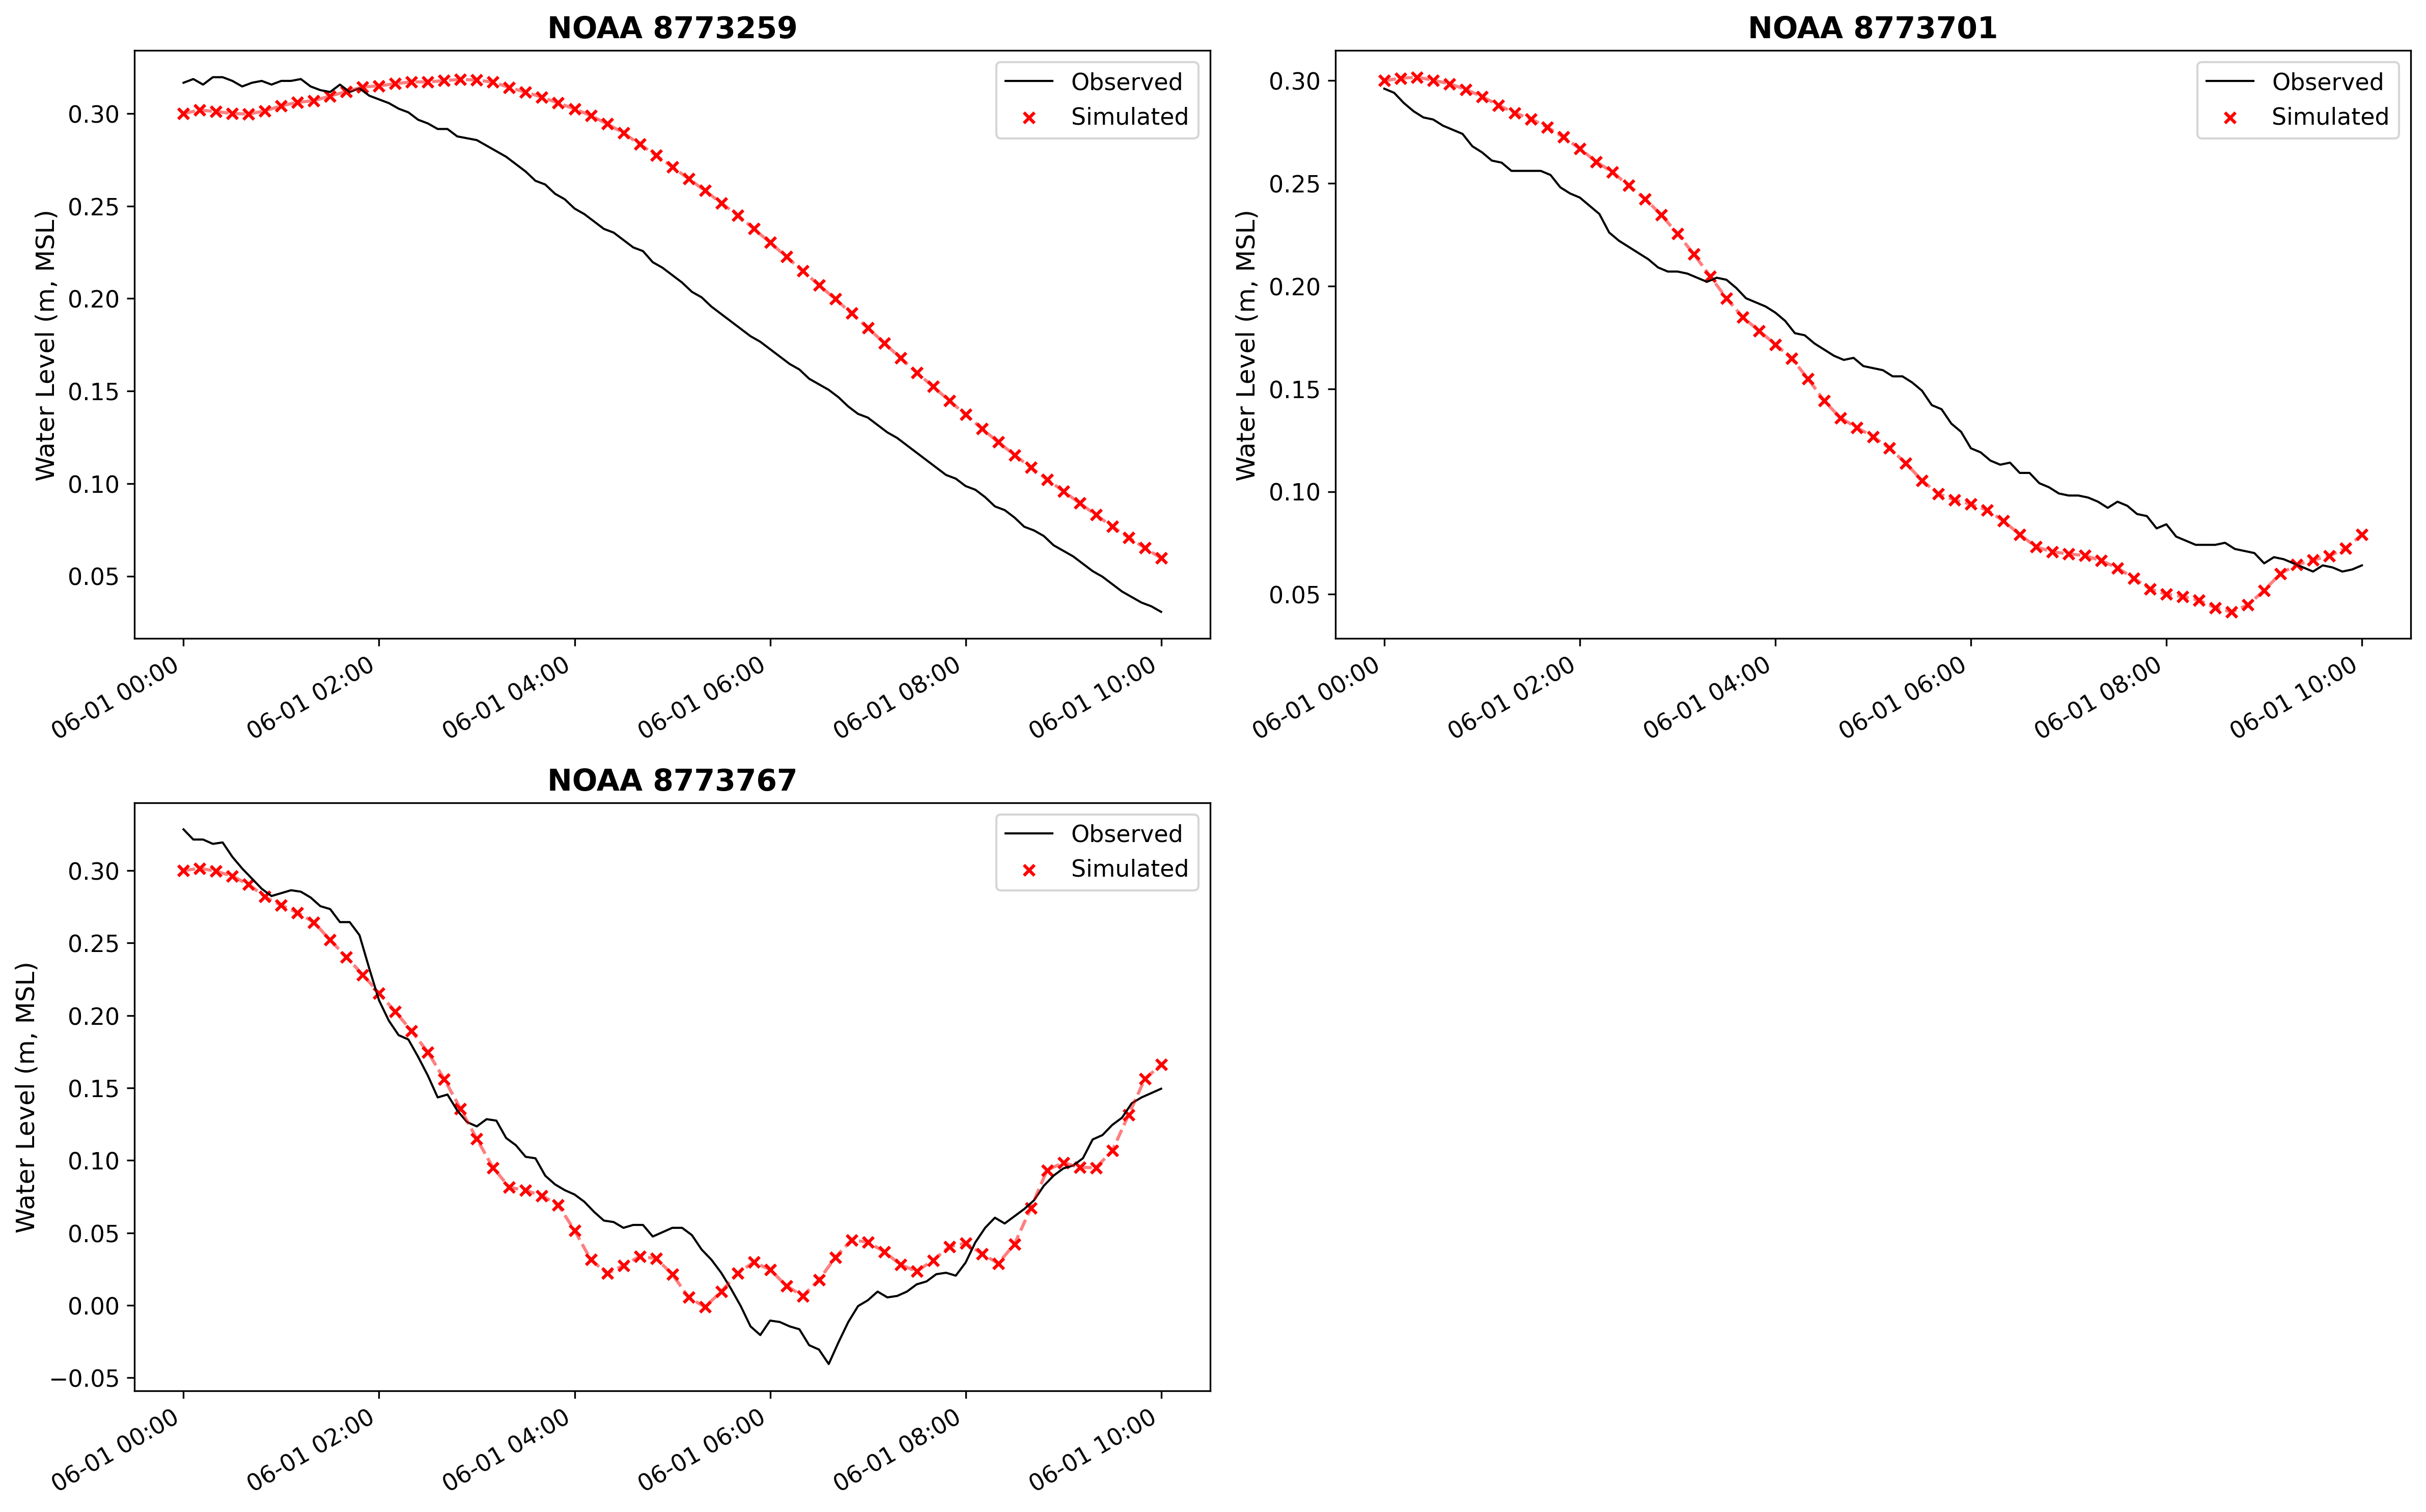

In [7]:
from IPython.display import Image, display

figs_dir = Path("run/sfincs_model/figs")
assert figs_dir.exists(), f"Results not found: {figs_dir.resolve()} — run the pipeline first."

for png in sorted(figs_dir.glob("stations_comparison_*.png")):
    display(Image(filename=str(png), width=800))

## 4. Quadtree mesh

The SFINCS model uses a quadtree grid with local refinement.  Coarser
cells (512 m) cover the offshore domain while regions near the coastline
and inside the bay are refined to smaller cell sizes (down to 64 m).
The map output file (`sfincs_map.nc`) stores the mesh as standard UGRID
quadrilaterals — opening it in QGIS with *native mesh rendering*
immediately shows the refinement structure.

In [8]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
import xugrid as xu
from matplotlib.collections import PolyCollection
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from pyproj import CRS, Transformer

map_file = Path("run/sfincs_model/sfincs_map.nc")
assert map_file.exists(), f"Map output not found: {map_file.resolve()} — run the pipeline first."

ds = xu.open_dataset(map_file)
grid = ds.ugrid.grid
grid_crs = CRS.from_epsg(int(ds["inp"].attrs["epsg"]))

# Derive refinement level from cell size (the grid is in UTM metres).
fnc = grid.face_node_connectivity  # (n_face, 4) — all quads
node_x, node_y = grid.node_x, grid.node_y
cell_width = node_x[fnc].max(axis=1) - node_x[fnc].min(axis=1)
base_res = 512
level = np.round(np.log2(base_res / cell_width) + 1).astype(int)

# Print grid summary
levels, counts = np.unique(level, return_counts=True)
print(f"  Grid CRS:  EPSG:{grid_crs.to_epsg()}")
print(f"  Faces:     {grid.n_face:,}")
print(f"  Edges:     {grid.n_edge:,}")
for lv, cnt in zip(levels, counts, strict=True):
    print(f"  Level {lv}:   {cnt:>6,} cells ({base_res / 2 ** (lv - 1):.0f} m)")

  Grid CRS:  EPSG:32614
  Faces:     70,723
  Edges:     282,892
  Level 1:   23,471 cells (512 m)
  Level 2:      545 cells (256 m)
  Level 3:    1,087 cells (128 m)
  Level 4:   45,620 cells (64 m)


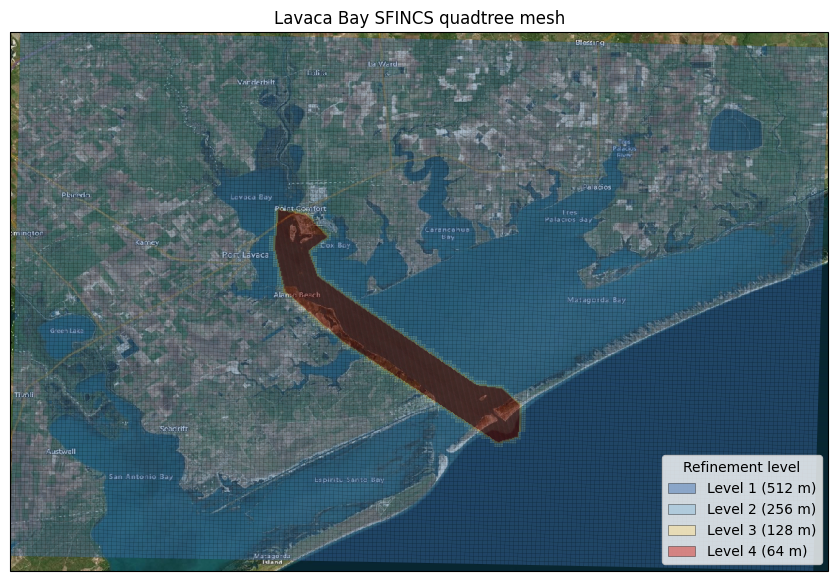

In [9]:
# Transform node coordinates to geographic CRS for the cartopy overlay.
transformer = Transformer.from_crs(grid_crs, "EPSG:4326", always_xy=True)
node_lon, node_lat = transformer.transform(node_x, node_y)

# Build vertex arrays for PolyCollection (all faces are quads).
n_verts = fnc.shape[1]
verts = np.zeros((grid.n_face, n_verts, 2))
for j in range(n_verts):
    verts[:, j, 0] = node_lon[fnc[:, j]]
    verts[:, j, 1] = node_lat[fnc[:, j]]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent(
    [node_lon.min(), node_lon.max(), node_lat.min(), node_lat.max()],
    crs=ccrs.PlateCarree(),
)

# Satellite background
tiles = cimgt.QuadtreeTiles()
ax.add_image(tiles, 11)

# Overlay mesh cells colored by refinement level
colors = ["#4575b4", "#91bfdb", "#fee090", "#d73027"]
cmap = ListedColormap(colors)
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], ncolors=4)

pc = PolyCollection(verts, edgecolors="black", linewidths=0.1, alpha=0.4)
pc.set_array(level.astype(float))
pc.set_cmap(cmap)
pc.set_norm(norm)
ax.add_collection(pc)

# Legend
legend_handles = [
    Patch(
        facecolor=cmap(norm(lv)),
        edgecolor="black",
        linewidth=0.5,
        alpha=0.5,
        label=f"Level {lv} ({base_res / 2 ** (lv - 1):.0f} m)",
    )
    for lv in levels
]
ax.legend(handles=legend_handles, loc="lower right", title="Refinement level")
ax.set_title("Lavaca Bay SFINCS quadtree mesh")
plt.show()

## 5. Flood depth map

When `floodmap_dem` is configured in `run.yaml`, the pipeline
automatically produces a downscaled flood depth map.  The
`sfincs_floodmap` stage reads the maximum water surface elevation
(`zsmax`) from the SFINCS map output, builds an index COG mapping DEM
pixels to SFINCS grid cells, and writes a Cloud Optimized GeoTIFF of
flood depth at the DEM resolution.

In [10]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
import rasterio

floodmap = Path("run/sfincs_model/floodmap_hmax.tif")
assert floodmap.exists(), (
    f"Flood map not found: {floodmap.resolve()} — "
    "ensure floodmap_dem is set in run.yaml and sfincs_map.nc contains zsmax."
)

# Print metadata at full resolution, then read at a coarser overview
# for display — the full raster can be too large for cartopy to render.
with rasterio.open(floodmap) as src:
    bounds = src.bounds
    raster_crs = src.crs
    print(f"  CRS:          {raster_crs}")
    print(f"  Size:         {src.width} x {src.height}")
    res_unit = raster_crs.linear_units if raster_crs.is_projected else "deg"
    print(f"  Resolution:   {abs(src.res[0]):.6g} x {abs(src.res[1]):.6g} {res_unit}")
    print(f"  File size:    {floodmap.stat().st_size / 1e6:.1f} MB")
    overviews = src.overviews(1)
    # Pick an overview that gives roughly 2000 px on the longest axis.
    ovr_idx = next(
        (i for i, f in enumerate(overviews) if max(src.height, src.width) / f <= 2000),
        len(overviews) - 1,
    )

with rasterio.open(floodmap, overview_level=ovr_idx) as src:
    hmax = src.read(1)
    print(f"  Display size: {src.width} x {src.height} (overview {overviews[ovr_idx]}x)")

# Mask dry / NaN pixels.  The floodmap already contains NaN outside the
# SFINCS domain and where depth < hmin, so no extra DEM masking is needed.
hmax_masked = np.where(np.isfinite(hmax) & (hmax > 0), hmax, np.nan)
valid = np.isfinite(hmax_masked)
print(f"  Valid pixels: {valid.sum():,} / {hmax.size:,} ({valid.sum() / hmax.size:.1%})")
if valid.any():
    print(f"  Depth range:  {np.nanmin(hmax_masked):.2f} - {np.nanmax(hmax_masked):.2f} m")

  CRS:          EPSG:4269
  Size:         15330 x 9949
  Resolution:   6.17284e-05 x 6.17284e-05 deg
  File size:    150.2 MB
  Display size: 1917 x 1244 (overview 8x)
  Valid pixels: 603,642 / 2,384,748 (25.3%)
  Depth range:  0.05 - 38.21 m


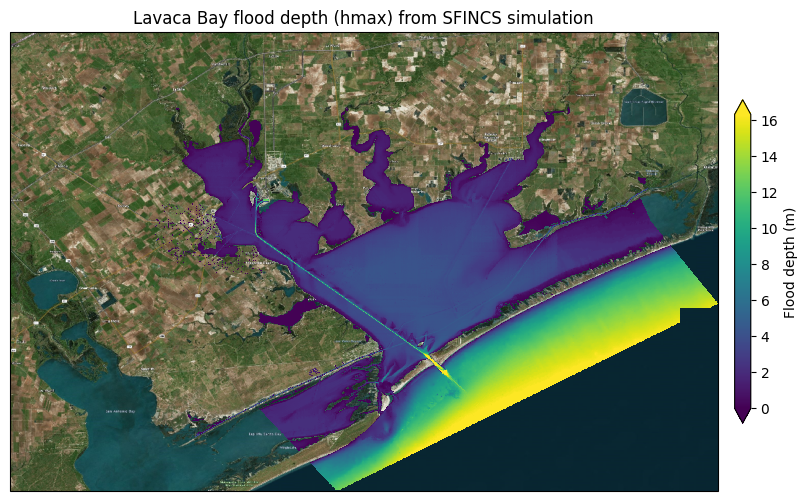

In [11]:
# Build a cartopy projection that matches the raster CRS.
if raster_crs.is_projected:
    proj = ccrs.epsg(raster_crs.to_epsg())
    data_crs = proj
else:
    proj = ccrs.PlateCarree()
    data_crs = ccrs.PlateCarree()

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(extent, crs=data_crs)

# Satellite background tiles
tiles = cimgt.QuadtreeTiles()
ax.add_image(tiles, 12)

# Overlay flood depth — use a masked array so cartopy renders
# invalid pixels as fully transparent over the satellite tiles.
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)
hmax_plot = np.ma.masked_invalid(hmax_masked)

im = ax.imshow(
    hmax_plot,
    extent=extent,
    origin="upper",
    transform=data_crs,
    cmap=cmap,
    vmin=0,
    vmax=np.nanpercentile(hmax_masked, 98),
    interpolation="nearest",
    zorder=2,
)
fig.colorbar(im, ax=ax, label="Flood depth (m)", shrink=0.6, pad=0.02, extend="both")
ax.set_title("Lavaca Bay flood depth (hmax) from SFINCS simulation")
plt.show()

The flood depth COG can also be opened directly in QGIS or any GIS
viewer.  For standalone usage outside the pipeline see the API
notebook or use:

```python
from coastal_calibration.utils.floodmap import create_flood_depth_map

create_flood_depth_map(
    model_root="run/sfincs_model",
    dem_path="../downloads/lavaca_grid/noaa_3m.tif",
)
```

## Summary

This notebook demonstrated the full Lavaca Bay SFINCS workflow via the CLI:

1. `coastal-calibration create create.yaml` — built the model from an AOI
2. `coastal-calibration run run.yaml` — downloaded data, ran SFINCS, and
   compared results against NOAA observations
3. Inspected the quadtree mesh and its refinement levels
4. Visualized the downscaled flood depth map (`floodmap_hmax.tif`)